In [1]:
try:
    import ipyvolume as ipv
except:
    !jupyter nbextension enable --py --sys-prefix ipyvolume
    import ipyvolume as ipv 

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from pathlib import Path

import re
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [3]:
RANDOM_STATE = 42
df = pd.read_parquet("year_Virgo_results_cut/qtransform_features.parquet")

feature_columns = [col for col in df.columns if col.startswith("feature_")]
if len(feature_columns) == 0:
    raise ValueError("No feature_* columns found.")

print(f"Number of features: {len(feature_columns)}")

X = df[feature_columns].to_numpy(dtype="float64")
print(f"X.shape = {X.shape}")

X_max = X.max(axis=1, keepdims=True)
#X_max = X_max.T
#print(X_max[0])

Number of features: 1230
X.shape = (8235, 1230)


In [4]:
for row in X:
    X_norm = X / X_max

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_norm)
print(f"Scaled matrix: {X_scaled.shape}") 

Scaled matrix: (8235, 1230)


In [5]:
PCA_COMPONENTS = 40

n_components = min(PCA_COMPONENTS,X_scaled.shape[0] - 1,X_scaled.shape[1])
pca = PCA(n_components=n_components,random_state=RANDOM_STATE)

X_pca = pca.fit_transform(X_scaled)
explained_variance = np.sum(pca.explained_variance_ratio_)

print(f"PCA components: {n_components}")
print(f"Explained variance: {explained_variance:.4f}")

tsne = TSNE(n_components=2,perplexity=90,early_exaggeration=14,init="pca",learning_rate="auto",random_state=RANDOM_STATE, metric='cosine')
X_tsne = tsne.fit_transform(X_pca)

PCA components: 40
Explained variance: 0.5384


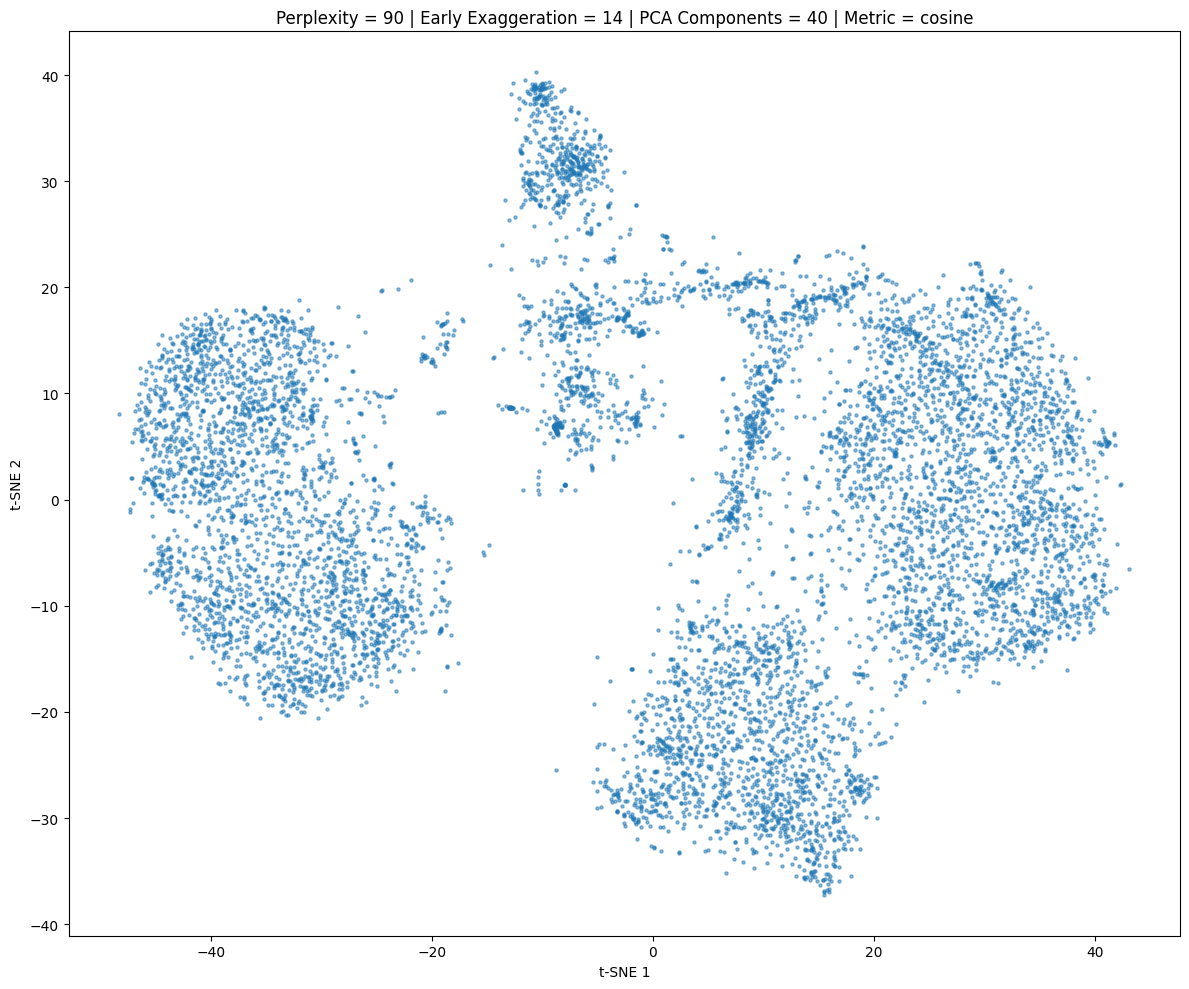

In [6]:
fig, ax = plt.subplots(figsize=(12, 10))
scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1],s=5,alpha=0.5)
ax.set_title(f"Perplexity = 90 | Early Exaggeration = 14 | PCA Components = {PCA_COMPONENTS} | Metric = cosine")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()

In [7]:
PCA_COMPONENTS = 40
n_components = min(PCA_COMPONENTS,X_scaled.shape[0] - 1,X_scaled.shape[1])
pca = PCA(n_components=n_components,random_state=RANDOM_STATE)

X_pca = pca.fit_transform(X_scaled)
explained_variance = np.sum(pca.explained_variance_ratio_)

print(f"PCA components: {n_components}")
print(f"Explained variance: {explained_variance:.4f}")

tsne = TSNE(n_components=3,perplexity=90,early_exaggeration=14,init="pca",learning_rate="auto",random_state=RANDOM_STATE, metric='cosine')
X_tsne = tsne.fit_transform(X_pca)

PCA components: 40
Explained variance: 0.5384


In [8]:
x, y, z = X_tsne[:, 0], X_tsne[:, 1], X_tsne[:, 2]
ipv.quickscatter(x, y, z, size=1, marker="sphere")

Container(figure=Figure(box_center=[0.5, 0.5, 0.5], box_size=[1.0, 1.0, 1.0], camera=PerspectiveCamera(fov=45.…

In [9]:
df_s1 = pd.read_parquet("year_Virgo_results_cut/qtransform_features.parquet")
df_s1 = df_s1.drop(columns=['year'])
df_s2 = pd.read_parquet("Virgo_results_cut/O3bqtransform_features.parquet")
df_s2 = df_s2.drop(columns=['run'])

df_s = pd.concat([df_s1, df_s2], ignore_index=True)

In [10]:
RANDOM_STATE = 42
df = df_s.copy()
feature_columns = [col for col in df.columns if col.startswith("feature_")]
if len(feature_columns) == 0:
    raise ValueError("No feature_* columns found.")

print(f"Number of features: {len(feature_columns)}")

X = df[feature_columns].to_numpy(dtype="float64")
print(f"X.shape = {X.shape}")

X_max = X.max(axis=1, keepdims=True)

Number of features: 1230
X.shape = (16552, 1230)


In [11]:
for row in X:
    X_norm = X / X_max

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_norm)
print(f"Scaled matrix: {X_scaled.shape}") 

Scaled matrix: (16552, 1230)


In [12]:
PCA_COMPONENTS = 40

n_components = min(PCA_COMPONENTS,X_scaled.shape[0] - 1,X_scaled.shape[1])
pca = PCA(n_components=n_components,random_state=RANDOM_STATE)

X_pca = pca.fit_transform(X_scaled)
explained_variance = np.sum(pca.explained_variance_ratio_)

print(f"PCA components: {n_components}")
print(f"Explained variance: {explained_variance:.4f}")

tsne = TSNE(n_components=2,perplexity=20,early_exaggeration=10,init="pca",learning_rate="auto",random_state=RANDOM_STATE, metric='euclidean')
X_tsne = tsne.fit_transform(X_pca)

PCA components: 40
Explained variance: 0.5534


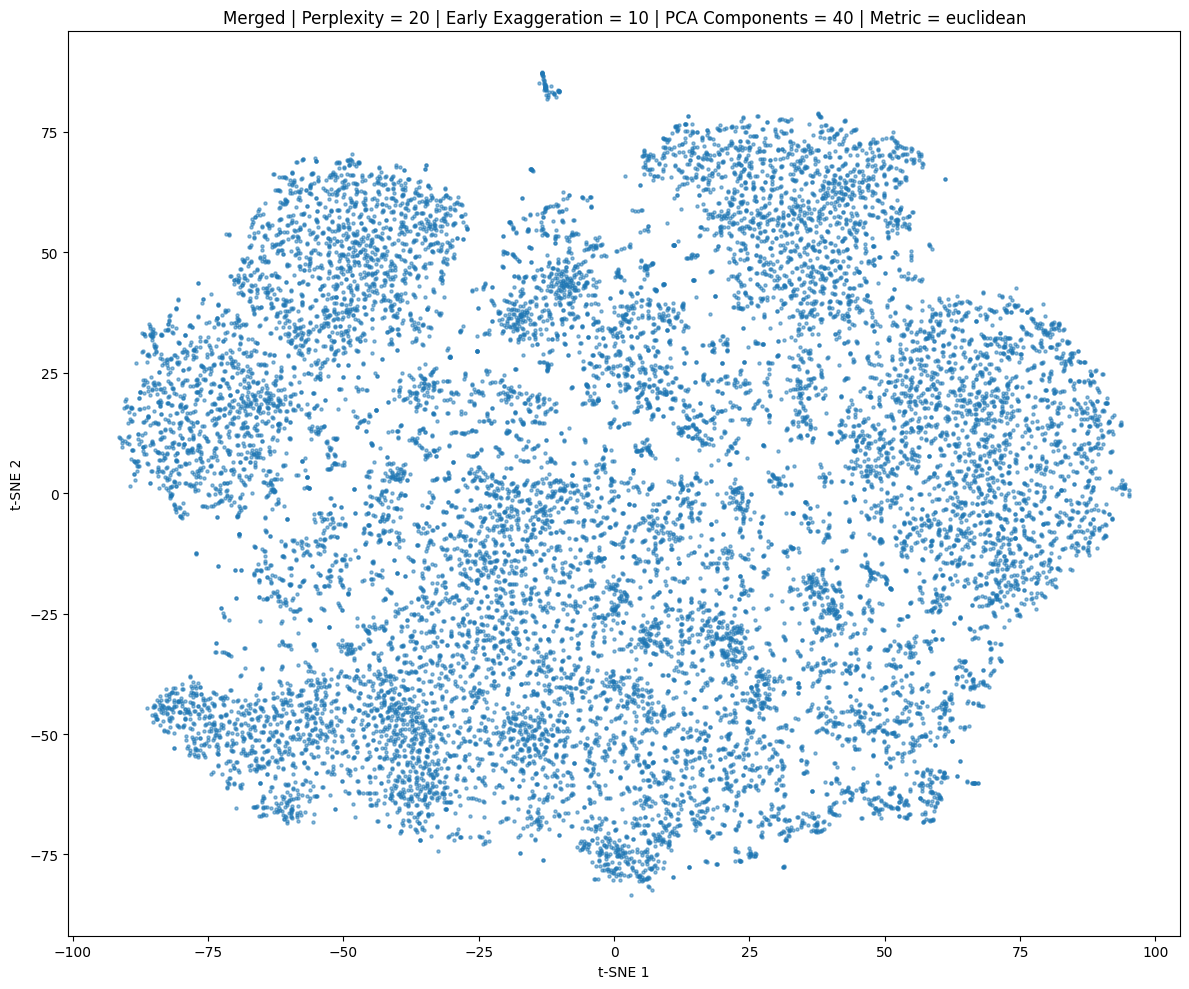

In [13]:
fig, ax = plt.subplots(figsize=(12, 10))
scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1],s=5,alpha=0.5)
ax.set_title(f"Merged | Perplexity = 20 | Early Exaggeration = 10 | PCA Components = {PCA_COMPONENTS} | Metric = euclidean")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()

In [14]:
PCA_COMPONENTS = 40
n_components = min(PCA_COMPONENTS,X_scaled.shape[0] - 1,X_scaled.shape[1])
pca = PCA(n_components=n_components,random_state=RANDOM_STATE)

X_pca = pca.fit_transform(X_scaled)
explained_variance = np.sum(pca.explained_variance_ratio_)

print(f"PCA components: {n_components}")
print(f"Explained variance: {explained_variance:.4f}")

tsne = TSNE(n_components=3,perplexity=90,early_exaggeration=14,init="pca",learning_rate="auto",random_state=RANDOM_STATE, metric='cosine')
X_tsne = tsne.fit_transform(X_pca)

PCA components: 40
Explained variance: 0.5534


In [15]:
x, y, z = X_tsne[:, 0], X_tsne[:, 1], X_tsne[:, 2]
ipv.quickscatter(x, y, z, size=1, marker="sphere")

Container(figure=Figure(box_center=[0.5, 0.5, 0.5], box_size=[1.0, 1.0, 1.0], camera=PerspectiveCamera(fov=45.…

In [16]:
#Now using only the HH3 station for VRG0x

df_s1 = pd.read_parquet("year_Virgo_results_cut/qtransform_features.parquet")
df_s1 = df_s1.drop(columns=['year'])
df_s2 = pd.read_parquet("Virgo_results_cut/O3bqtransform_features.parquet")
df_s2 = df_s2[df_s2["channel"] == 'HH3']
df_s2 = df_s2.drop(columns=['run'])

df_s = pd.concat([df_s1, df_s2], ignore_index=True)

In [17]:
RANDOM_STATE = 42
df = df_s.copy()
feature_columns = [col for col in df.columns if col.startswith("feature_")]
if len(feature_columns) == 0:
    raise ValueError("No feature_* columns found.")

print(f"Number of features: {len(feature_columns)}")

X = df[feature_columns].to_numpy(dtype="float64")
print(f"X.shape = {X.shape}")

X_max = X.max(axis=1, keepdims=True)

Number of features: 1230
X.shape = (12275, 1230)


In [18]:
for row in X:
    X_norm = X / X_max

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_norm)
print(f"Scaled matrix: {X_scaled.shape}") 

Scaled matrix: (12275, 1230)


In [19]:
PCA_COMPONENTS = 40

n_components = min(PCA_COMPONENTS,X_scaled.shape[0] - 1,X_scaled.shape[1])
pca = PCA(n_components=n_components,random_state=RANDOM_STATE)

X_pca = pca.fit_transform(X_scaled)
explained_variance = np.sum(pca.explained_variance_ratio_)

print(f"PCA components: {n_components}")
print(f"Explained variance: {explained_variance:.4f}")

tsne = TSNE(n_components=2,perplexity=20,early_exaggeration=10,init="pca",learning_rate="auto",random_state=RANDOM_STATE, metric='euclidean')
X_tsne = tsne.fit_transform(X_pca)

PCA components: 40
Explained variance: 0.5355


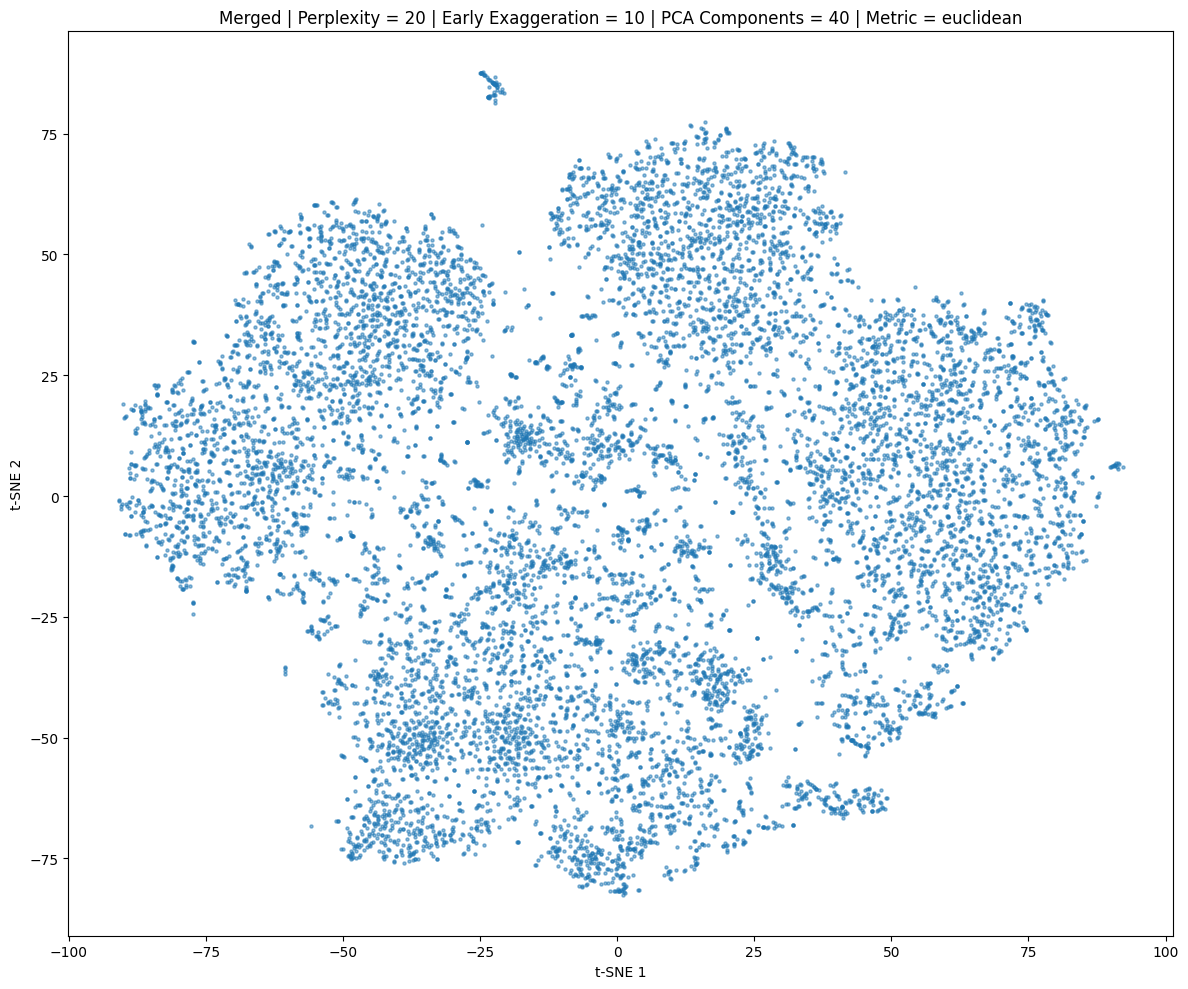

In [20]:
fig, ax = plt.subplots(figsize=(12, 10))
scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1],s=5,alpha=0.5)
ax.set_title(f"Merged | Perplexity = 20 | Early Exaggeration = 10 | PCA Components = {PCA_COMPONENTS} | Metric = euclidean")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()

In [21]:
PCA_COMPONENTS = 40
n_components = min(PCA_COMPONENTS,X_scaled.shape[0] - 1,X_scaled.shape[1])
pca = PCA(n_components=n_components,random_state=RANDOM_STATE)

X_pca = pca.fit_transform(X_scaled)
explained_variance = np.sum(pca.explained_variance_ratio_)

print(f"PCA components: {n_components}")
print(f"Explained variance: {explained_variance:.4f}")

tsne = TSNE(n_components=3,perplexity=90,early_exaggeration=14,init="pca",learning_rate="auto",random_state=RANDOM_STATE, metric='cosine')
X_tsne = tsne.fit_transform(X_pca)

PCA components: 40
Explained variance: 0.5355


In [22]:
x, y, z = X_tsne[:, 0], X_tsne[:, 1], X_tsne[:, 2]
ipv.quickscatter(x, y, z, size=1, marker="sphere")

Container(figure=Figure(box_center=[0.5, 0.5, 0.5], box_size=[1.0, 1.0, 1.0], camera=PerspectiveCamera(fov=45.…

In [23]:
#Finally, only HH3 for station VRG01

df_s1 = pd.read_parquet("year_Virgo_results_cut/qtransform_features.parquet")
df_s1 = df_s1.drop(columns=['year'])
df_s2 = pd.read_parquet("Virgo_results_cut/O3bqtransform_features.parquet")
df_s2 = df_s2[df_s2["channel"] == 'HH3']
df_s2 = df_s2[df_s2["station"] == 'VRG01']
df_s2 = df_s2.drop(columns=['run'])

df_s = pd.concat([df_s1, df_s2], ignore_index=True)

In [24]:
RANDOM_STATE = 42
df = df_s.copy()
feature_columns = [col for col in df.columns if col.startswith("feature_")]
if len(feature_columns) == 0:
    raise ValueError("No feature_* columns found.")

print(f"Number of features: {len(feature_columns)}")

X = df[feature_columns].to_numpy(dtype="float64")
print(f"X.shape = {X.shape}")

X_max = X.max(axis=1, keepdims=True)

Number of features: 1230
X.shape = (8771, 1230)


In [25]:
for row in X:
    X_norm = X / X_max

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_norm)
print(f"Scaled matrix: {X_scaled.shape}") 

Scaled matrix: (8771, 1230)


In [26]:
PCA_COMPONENTS = 40

n_components = min(PCA_COMPONENTS,X_scaled.shape[0] - 1,X_scaled.shape[1])
pca = PCA(n_components=n_components,random_state=RANDOM_STATE)

X_pca = pca.fit_transform(X_scaled)
explained_variance = np.sum(pca.explained_variance_ratio_)

print(f"PCA components: {n_components}")
print(f"Explained variance: {explained_variance:.4f}")

tsne = TSNE(n_components=2,perplexity=20,early_exaggeration=10,init="pca",learning_rate="auto",random_state=RANDOM_STATE, metric='euclidean')
X_tsne = tsne.fit_transform(X_pca)

PCA components: 40
Explained variance: 0.5374


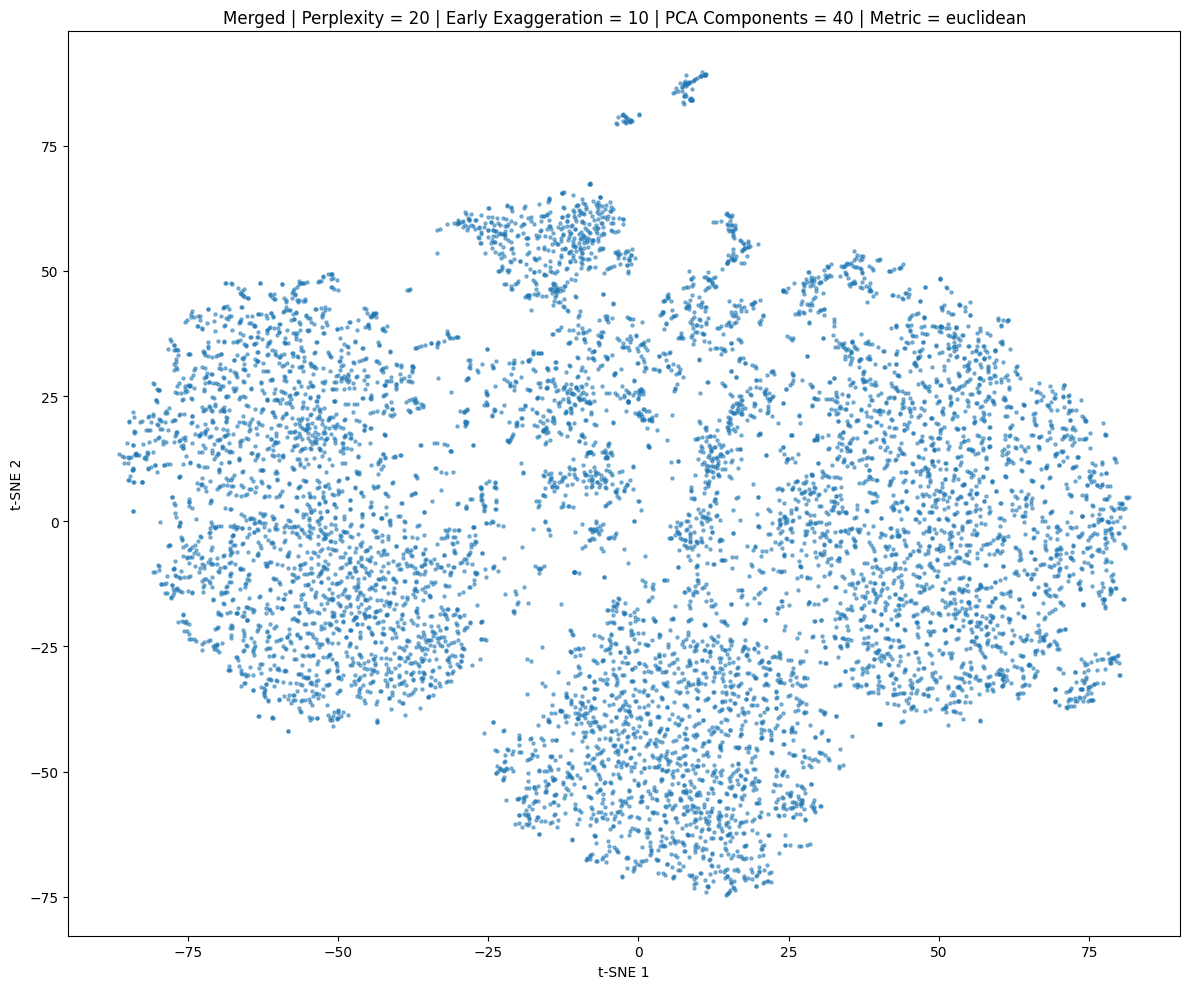

In [27]:
fig, ax = plt.subplots(figsize=(12, 10))
scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1],s=5,alpha=0.5)
ax.set_title(f"Merged | Perplexity = 20 | Early Exaggeration = 10 | PCA Components = {PCA_COMPONENTS} | Metric = euclidean")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()

In [28]:
PCA_COMPONENTS = 40
n_components = min(PCA_COMPONENTS,X_scaled.shape[0] - 1,X_scaled.shape[1])
pca = PCA(n_components=n_components,random_state=RANDOM_STATE)

X_pca = pca.fit_transform(X_scaled)
explained_variance = np.sum(pca.explained_variance_ratio_)

print(f"PCA components: {n_components}")
print(f"Explained variance: {explained_variance:.4f}")

tsne = TSNE(n_components=3,perplexity=90,early_exaggeration=14,init="pca",learning_rate="auto",random_state=RANDOM_STATE, metric='cosine')
X_tsne = tsne.fit_transform(X_pca)

PCA components: 40
Explained variance: 0.5374


In [29]:
x, y, z = X_tsne[:, 0], X_tsne[:, 1], X_tsne[:, 2]
ipv.quickscatter(x, y, z, size=1, marker="sphere")

Container(figure=Figure(box_center=[0.5, 0.5, 0.5], box_size=[1.0, 1.0, 1.0], camera=PerspectiveCamera(fov=45.…